                                           name    size
0                                         flare     NaN
1                               flare.analytics     NaN
2                       flare.analytics.cluster     NaN
3  flare.analytics.cluster.AgglomerativeCluster  3938.0
4    flare.analytics.cluster.CommunityStructure  3812.0
name     0
size    32
dtype: int64
=== Random Forest Results ===
Accuracy: 0.0

Classification Report:
               precision    recall  f1-score   support

       277.0       0.00      0.00      0.00       1.0
       283.0       0.00      0.00      0.00       1.0
       287.0       0.00      0.00      0.00       0.0
       296.0       0.00      0.00      0.00       1.0
       299.0       0.00      0.00      0.00       1.0
       307.0       0.00      0.00      0.00       1.0
       330.0       0.00      0.00      0.00       1.0
       335.0       0.00      0.00      0.00       2.0
       353.0       0.00      0.00      0.00       1.0
       363.0       

/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:830: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/tree/_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/tree/_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/tree/_classes.py:297:


=== Extra Trees Results ===
Accuracy: 0.0

Classification Report:
               precision    recall  f1-score   support

       277.0       0.00      0.00      0.00       1.0
       283.0       0.00      0.00      0.00       1.0
       296.0       0.00      0.00      0.00       1.0
       299.0       0.00      0.00      0.00       1.0
       307.0       0.00      0.00      0.00       1.0
       330.0       0.00      0.00      0.00       1.0
       335.0       0.00      0.00      0.00       2.0
       353.0       0.00      0.00      0.00       1.0
       363.0       0.00      0.00      0.00       1.0
       600.0       0.00      0.00      0.00       1.0
       603.0       0.00      0.00      0.00       0.0
       721.0       0.00      0.00      0.00       1.0
       748.0       0.00      0.00      0.00       1.0
      1027.0       0.00      0.00      0.00       1.0
      1117.0       0.00      0.00      0.00       1.0
      1124.0       0.00      0.00      0.00       1.0
      1229.0 

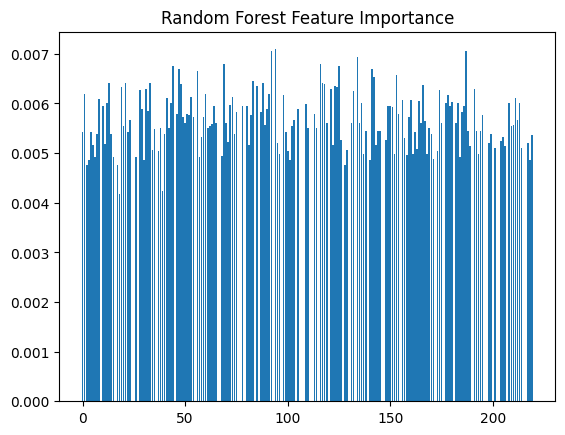

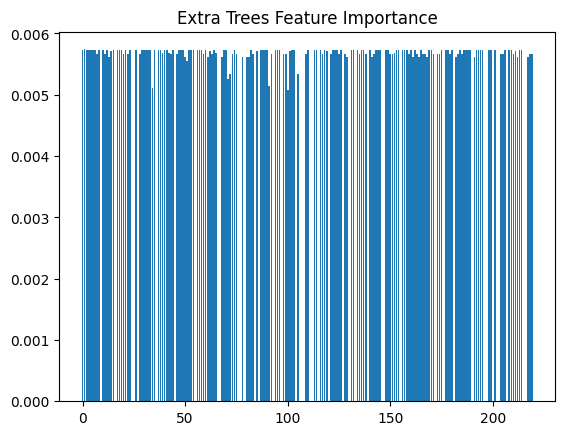

In [1]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==============================
# 2. Load Dataset
# ==============================
# Replace with your actual path
df = pd.read_csv('flare.csv')

# Preview data
print(df.head())

# ==============================
# 3. Data Preprocessing
# ==============================

# Check for missing values
print(df.isnull().sum())

# Drop missing values (or use fillna if preferred)
df = df.dropna()

# Separate features and target
# Assuming last column is the target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Convert categorical columns (if any)
X = pd.get_dummies(X)

# ==============================
# 4. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 5. Random Forest Model
# ==============================
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)

# Evaluation
print("=== Random Forest Results ===")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("\nClassification Report:\n", classification_report(y_test, rf_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_preds))

# ==============================
# 6. Extra Trees (Random Trees)
# ==============================
et_model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42
)

et_model.fit(X_train, y_train)

# Predictions
et_preds = et_model.predict(X_test)

# Evaluation
print("\n=== Extra Trees Results ===")
print("Accuracy:", accuracy_score(y_test, et_preds))
print("\nClassification Report:\n", classification_report(y_test, et_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, et_preds))

# ==============================
# 7. Feature Importance
# ==============================
import matplotlib.pyplot as plt

# Random Forest Feature Importance
rf_importances = rf_model.feature_importances_

plt.figure()
plt.title("Random Forest Feature Importance")
plt.bar(range(len(rf_importances)), rf_importances)
plt.show()

# Extra Trees Feature Importance
et_importances = et_model.feature_importances_

plt.figure()
plt.title("Extra Trees Feature Importance")
plt.bar(range(len(et_importances)), et_importances)
plt.show()